In [1]:
#import Library
import xarray as xr
import rioxarray as rxr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Open/Read Precipitation Dataset

In [ ]:
#open precipitation dataset
chirp_path = r"D:\Raster\precip_2025.tif"
open_pr = rxr.open_rasterio(chirp_path, masked=True)
open_pr

<xarray.DataArray (band: 12, y: 631, x: 866)> Size: 52MB
[6557352 values with dtype=float64]
Coordinates:
  * band         (band) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * x            (x) float64 7kB -1.789e+06 -1.788e+06 ... -1.702e+06 -1.702e+06
  * y            (y) float64 5kB 1.062e+07 1.062e+07 ... 1.056e+07 1.056e+07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Month_01', 'Month_02', 'Month_03', 'Month_04', 'Month_0...

#### Visualization of Monthly Precipitation

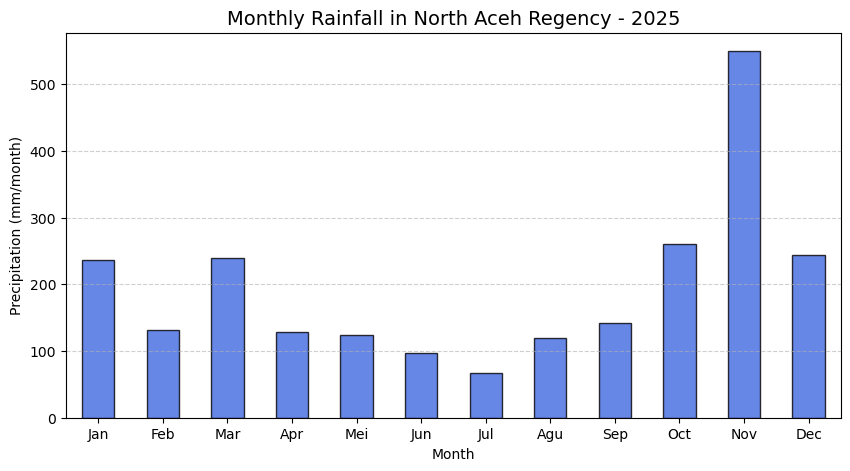

In [11]:
#Calculate Spatial Average (Reduce x and y dimensions to 1 number per band)
monthly_avg = open_pr.mean(dim=['x', 'y'])

#Change to pandas
df_pr = monthly_avg.to_series()

#Visulization Bar Chart

plt.figure(figsize=(10, 5))
df_pr.plot.bar(color='royalblue', edgecolor='black', alpha=0.8)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(12), months, rotation=0)
plt.title('Monthly Rainfall in North Aceh Regency - 2025', fontsize=14)
plt.ylabel('Precipitation (mm/month)')
plt.xlabel('Month')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

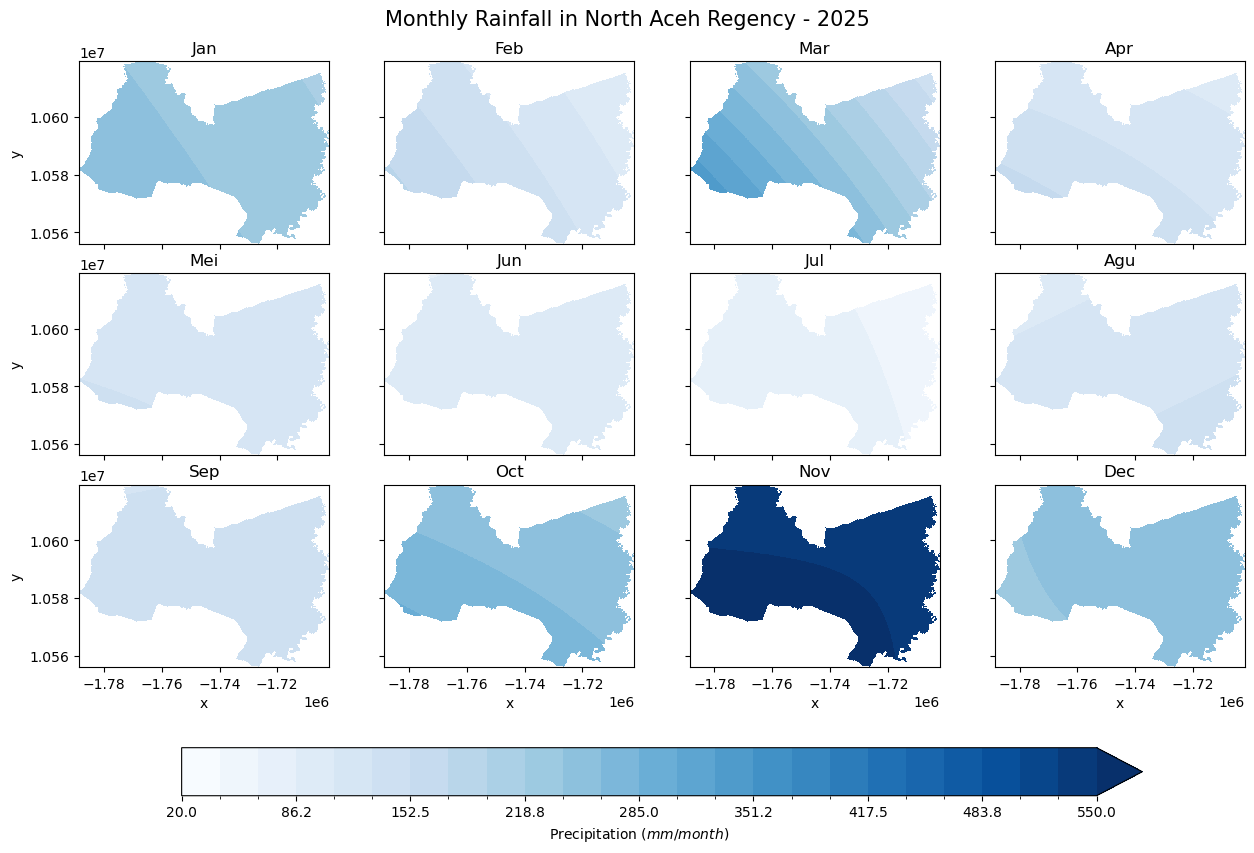

In [22]:
# Setup Plotting
vis_pr = open_pr.plot.imshow(
    col='band',       # Use a dimension that distinguishes months (e.g.: 'band' or 'month')
    col_wrap=4,       # 4 columns per row to fit into 3 rows (3x4=12)
    cmap='Blues',     # Blue color is suitable for rainfall
    robust=True,      # Remove outliers for good color contrast
    levels = 25,
    vmin= 20,
    vmax= 550,
    cbar_kwargs={
        'label': 'Precipitation ($mm/month$)',
        'orientation': 'horizontal',
        'shrink': 0.8,
        'pad': 0.1
    }
)

# Visualization setting
months = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Oct', 'Nov', 'Dec']
for ax, month in zip(vis_pr.axs.flat, months):
    ax.set_title(month)
    ax.set_aspect('equal') # arrange this so that the geographical shape fits

plt.suptitle('Monthly Rainfall in North Aceh Regency - 2025', y=1.02, fontsize=15)
plt.show()

#### Flood Prediction Using Sentinel 1

In [ ]:
#open Sentinel 1 SAR
sar_path = r"D:\Raster\S1_AcehUtara_Flood_Event.tif"
open_sar = rxr.open_rasterio(sar_path, masked=True)
open_sar

<xarray.DataArray (band: 4, y: 586, x: 813)> Size: 15MB
[1905672 values with dtype=float64]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 7kB 96.79 96.79 96.79 96.79 ... 97.51 97.52 97.52
  * y            (y) float64 5kB 5.263 5.262 5.261 5.26 ... 4.739 4.738 4.737
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('VV_Okt', 'VH_Okt', 'VV_Nov', 'VH_Nov')

In [3]:
#Separate the Bands for easy counting
before = open_sar.sel(band=1)
after = open_sar.sel(band=3)

#Calculate the Difference (Difference / Log-Ratio)
flood_detection = before - after

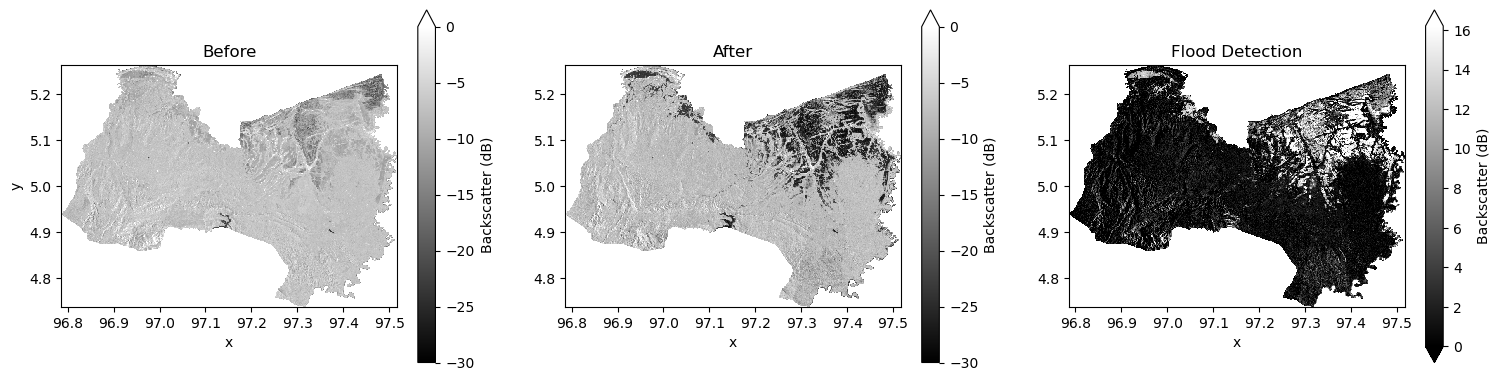

In [4]:
#visualization
fig, ax = plt.subplots(1,3, figsize=(15, 5))
plt.tight_layout(w_pad=3)

#ax.set_aspect('equal')
plot1 = before.plot(
    x = 'x',
    y = 'y',
    robust = True,
    cmap = 'gray',
    ax = ax[0],
    vmin = -30,
    vmax = 0,
    cbar_kwargs={'label': 'Backscatter (dB)', 'shrink': 0.8}
)
ax[0].set_title('Before')

plot2 = after.plot(
    x = 'x',
    y = 'y',
    robust = True,
    cmap = 'gray',
    ax = ax[1],
    vmin = -30,
    vmax = 0,
    cbar_kwargs={'label': 'Backscatter (dB)', 'shrink': 0.8}
)
ax[1].set_title('After')

plot3 = flood_detection.plot(
    x = 'x',
    y = 'y',
    robust = True,
    cmap = 'gray',
    ax = ax[2],
    vmin=0,
    cbar_kwargs={'label': 'Backscatter (dB)', 'shrink': 0.8}
)
ax[2].set_title('Flood Detection')

# Opsional
for a in ax:
    a.set_aspect('equal')

ax[1].set_ylabel('')
ax[2].set_ylabel('')
plt.show()